In [0]:
# ============================================================
# Carnot Data Engineer Assignment — Full Pipeline
# Notebook: 00_data_audit
# Author: Harshal
# ============================================================

# File paths
READINGS_PATH = "/Volumes/workspace/cornetschema/cornet/parcel_readings.csv"
METADATA_PATH = "/Volumes/workspace/cornetschema/cornet/parcel_metadata.csv"
OUTPUT_PATH   = "/Volumes/workspace/cornetschema/cornet/cleaned_parcel_timeseries"

print("Paths configured")

Paths configured


In [0]:
# ============================================================
# CELL 1 — GLOBAL IMPORTS & RAW INGEST
# ============================================================

from pyspark.sql.functions import (
    col,
    upper,
    trim,
    when,
    coalesce,
    expr,
    datediff,
    avg,
    countDistinct,
    round as spark_round,
    count as spark_count
)

READINGS_PATH = "/Volumes/workspace/cornetschema/cornet/parcel_readings.csv"
METADATA_PATH = "/Volumes/workspace/cornetschema/cornet/parcel_metadata.csv"
OUTPUT_PATH   = "/Volumes/workspace/cornetschema/cornet/cleaned_parcel_timeseries"

readings_raw = spark.read.csv(READINGS_PATH, header=True, inferSchema=True)
metadata_raw = spark.read.csv(METADATA_PATH, header=True, inferSchema=True)

print("Imports loaded")
print("Raw data loaded")
print(f"   readings : {readings_raw.count()} rows")
print(f"   metadata : {metadata_raw.count()} rows")

Imports loaded
Raw data loaded
   readings : 3447 rows
   metadata : 28 rows


In [0]:
# ============================================================
# SECTION 1 — INGEST (Bronze Layer)
# ============================================================

readings_raw = spark.read.csv(READINGS_PATH, header=True, inferSchema=True)
metadata_raw = spark.read.csv(METADATA_PATH, header=True, inferSchema=True)

print(f"readings shape : {readings_raw.count()} rows × {len(readings_raw.columns)} cols")
print(f"metadata shape : {metadata_raw.count()} rows × {len(metadata_raw.columns)} cols")

print("\n--- Readings Schema ---")
readings_raw.printSchema()

print("\n--- Metadata Schema ---")
metadata_raw.printSchema()

readings shape : 3447 rows × 6 cols
metadata shape : 28 rows × 5 cols

--- Readings Schema ---
root
 |-- parcel_id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- ndvi_value: double (nullable = true)
 |-- temperature_c: double (nullable = true)
 |-- rainfall_mm: double (nullable = true)
 |-- sensor_status: string (nullable = true)


--- Metadata Schema ---
root
 |-- parcel_id: string (nullable = true)
 |-- mill_id: string (nullable = true)
 |-- crop_type: string (nullable = true)
 |-- sowing_date: date (nullable = true)
 |-- area_hectares: double (nullable = true)



In [0]:
# ============================================================
# SECTION 2 — DATA QUALITY AUDIT
# ============================================================

from pyspark.sql.functions import count as spark_count

total = readings_raw.count()
print(f"Total readings rows: {total}\n")

audit = readings_raw.select(
    spark_count(when(col("ndvi_value").isNull(), 1)).alias("ndvi_nulls"),
    spark_count(when(col("temperature_c").isNull(), 1)).alias("temp_nulls"),
    spark_count(when(col("rainfall_mm").isNull(), 1)).alias("rainfall_nulls"),
    spark_count(when(col("sensor_status").isNull(), 1)).alias("sensor_status_nulls"),
    spark_count(when(col("ndvi_value") < -1, 1)).alias("ndvi_below_minus1"),
    spark_count(when(col("ndvi_value") > 1, 1)).alias("ndvi_above_1"),
    spark_count(when(col("rainfall_mm") < 0, 1)).alias("negative_rainfall"),
).collect()[0]

print("=== Quality Report: parcel_readings ===")
for field, value in audit.asDict().items():
    pct    = round(value / total * 100, 2)
    status = "FAIL" if value > 0 else "PASS"
    print(f"  {status}  {field}: {value} rows ({pct}%)")

print("\n--- sensor_status unique values ---")
readings_raw.groupBy("sensor_status").count().orderBy("count", ascending=False).show()

dupes = readings_raw.count() - readings_raw.dropDuplicates(["parcel_id","date"]).count()
print(f"Duplicate parcel+date rows: {dupes}")

r_ids = readings_raw.select("parcel_id").distinct()
m_ids = metadata_raw.select("parcel_id").distinct()

print("\n--- Orphan parcel IDs (in readings, not in metadata) ---")
r_ids.subtract(m_ids).show()

print("--- Metadata parcels with no readings ---")
m_ids.subtract(r_ids).show()

Total readings rows: 3447

=== Quality Report: parcel_readings ===
  PASS  ndvi_nulls: 0 rows (0.0%)
  PASS  temp_nulls: 0 rows (0.0%)
  PASS  rainfall_nulls: 0 rows (0.0%)
  FAIL  sensor_status_nulls: 43 rows (1.25%)
  FAIL  ndvi_below_minus1: 51 rows (1.48%)
  FAIL  ndvi_above_1: 53 rows (1.54%)
  PASS  negative_rainfall: 0 rows (0.0%)

--- sensor_status unique values ---
+-------------+-----+
|sensor_status|count|
+-------------+-----+
|           OK| 2890|
|        Error|   90|
|        ERROR|   80|
|        error|   76|
|           ok|   64|
|          OK |   57|
|           NA|   53|
|           OK|   53|
|         NULL|   43|
|          NaN|   41|
+-------------+-----+

Duplicate parcel+date rows: 8

--- Orphan parcel IDs (in readings, not in metadata) ---
+----------+
| parcel_id|
+----------+
|PARCEL_098|
|PARCEL_099|
+----------+

--- Metadata parcels with no readings ---
+----------+
| parcel_id|
+----------+
|PARCEL_052|
|PARCEL_050|
|PARCEL_051|
+----------+



In [0]:
# ============================================================
# SECTION 3 — CLEAN (Silver Layer)
# ============================================================

readings = readings_raw

# 3a — Normalise dates
readings = readings.withColumn(
    "date",
    coalesce(
        expr("try_to_date(date, 'yyyy-MM-dd')"),
        expr("try_to_date(date, 'dd/MM/yyyy')"),
        expr("try_to_date(date, 'dd-MMM-yyyy')")
    )
)
print(f"Null dates after parsing: {readings.filter(col('date').isNull()).count()}")

# 3b — Normalise sensor_status
readings = readings.withColumn(
    "sensor_status",
    when(col("sensor_status").isNull(), "UNKNOWN")
    .when(upper(trim(col("sensor_status"))).isin("NA", "NAN", "N/A", "NONE"), "UNKNOWN")
    .otherwise(upper(trim(col("sensor_status"))))
)

# 3c — Flag & null out-of-range NDVI
readings = readings.withColumn(
    "ndvi_flag",
    (col("ndvi_value") < -1) | (col("ndvi_value") > 1)
).withColumn(
    "ndvi_value",
    when((col("ndvi_value") < -1) | (col("ndvi_value") > 1), None)
    .otherwise(col("ndvi_value"))
)

# 3d — Drop duplicates
before = readings.count()
readings = readings.dropDuplicates()
mid = readings.count()
readings = readings.dropDuplicates(["parcel_id", "date"])
after = readings.count()
print(f"Exact duplicates removed      : {before - mid}")
print(f"Parcel+date duplicates removed: {mid - after}")
print(f"Total duplicate rows removed  : {before - after}")

# 3e — Drop orphan parcels
orphan_ids = ["PARCEL_098", "PARCEL_099"]
before_orphan = readings.count()
readings = readings.filter(~col("parcel_id").isin(orphan_ids))
print(f"Orphan rows dropped           : {before_orphan - readings.count()}")

# 3f — metadata (sowing_date already date type)
metadata = metadata_raw

print(f"\nClean readings rows : {readings.count()}")
print(f"Clean metadata rows : {metadata.count()}")

print("\n--- Sanity Checks ---")
print(f"Null dates    : {readings.filter(col('date').isNull()).count()}")
print(f"Orphans left  : {readings.filter(col('parcel_id').isin(orphan_ids)).count()}")
print(f"NDVI errors   : {readings.filter((col('ndvi_value') < -1) | (col('ndvi_value') > 1)).count()}")
print("\nsensor_status values:")
readings.groupBy("sensor_status").count().orderBy("count", ascending=False).show()

Null dates after parsing: 0
Exact duplicates removed      : 0
Parcel+date duplicates removed: 8
Total duplicate rows removed  : 8
Orphan rows dropped           : 40

Clean readings rows : 3399
Clean metadata rows : 28

--- Sanity Checks ---
Null dates    : 0
Orphans left  : 0
NDVI errors   : 0

sensor_status values:
+-------------+-----+
|sensor_status|count|
+-------------+-----+
|           OK| 3017|
|        ERROR|  245|
|      UNKNOWN|  137|
+-------------+-----+



In [0]:
# ============================================================
# SECTION 4 — JOIN
# ============================================================

df = readings.join(metadata, on="parcel_id", how="inner")

df = df.select(
    "parcel_id", "mill_id", "crop_type", "area_hectares",
    "sowing_date", "date",
    "ndvi_value", "ndvi_flag",
    "temperature_c", "rainfall_mm", "sensor_status"
).orderBy("parcel_id", "date")

print(f"Joined dataset: {df.count()} rows × {len(df.columns)} cols")
df.show(10)

Joined dataset: 3399 rows × 11 cols
+----------+----------+---------+-------------+-----------+----------+----------+---------+-------------+-----------+-------------+
| parcel_id|   mill_id|crop_type|area_hectares|sowing_date|      date|ndvi_value|ndvi_flag|temperature_c|rainfall_mm|sensor_status|
+----------+----------+---------+-------------+-----------+----------+----------+---------+-------------+-----------+-------------+
|PARCEL_001|MILL_NORTH|sugarcane|         9.03| 2026-02-10|2026-01-01|      0.17|    false|         33.9|        0.0|           OK|
|PARCEL_001|MILL_NORTH|sugarcane|         9.03| 2026-02-10|2026-01-02|     0.214|    false|         20.9|        8.4|           OK|
|PARCEL_001|MILL_NORTH|sugarcane|         9.03| 2026-02-10|2026-01-03|     0.118|    false|         27.5|        0.0|           OK|
|PARCEL_001|MILL_NORTH|sugarcane|         9.03| 2026-02-10|2026-01-04|     0.342|    false|         27.0|        0.0|           OK|
|PARCEL_001|MILL_NORTH|sugarcane|       

In [0]:
# ============================================================
# SECTION 6 — WRITE OUTPUT
# ============================================================

df.write \
  .format("delta") \
  .mode("overwrite") \
  .save(OUTPUT_PATH)

print(f"Cleaned timeseries → {OUTPUT_PATH}")
print(f"   Rows: {df.count():,}")

analysis.write \
  .format("delta") \
  .mode("overwrite") \
  .save("/Volumes/workspace/cornetschema/cornet/ndvi_analysis")

print("Analysis → /Volumes/workspace/cornetschema/cornet/ndvi_analysis")

Cleaned timeseries → /Volumes/workspace/cornetschema/cornet/cleaned_parcel_timeseries
   Rows: 3,399
Analysis → /Volumes/workspace/cornetschema/cornet/ndvi_analysis


In [0]:
# ============================================================
# SECTION 5 — ANALYSIS (Gold Layer)
# ============================================================

# Only OK sensor readings
good = df.filter(col("sensor_status") == "OK")
print(f"Rows with OK sensor status: {good.count()}")

# Days relative to sowing
good = good.withColumn(
    "days_from_sowing",
    datediff(col("date"), col("sowing_date"))
)

# Windows
before = good.filter(
    (col("days_from_sowing") >= -30) & (col("days_from_sowing") < 0)
)
after = good.filter(
    (col("days_from_sowing") >= 0) & (col("days_from_sowing") < 30)
)

print(f"Rows in before window : {before.count()}")
print(f"Rows in after window  : {after.count()}")

# Aggregations
ndvi_before = before.groupBy("crop_type").agg(
    spark_round(avg("ndvi_value"), 4).alias("mean_ndvi_before")
)
ndvi_after = after.groupBy("crop_type").agg(
    spark_round(avg("ndvi_value"), 4).alias("mean_ndvi_after")
)
n_parcels = good.groupBy("crop_type").agg(
    countDistinct("parcel_id").alias("n_parcels")
)

# Final analysis table
analysis = ndvi_before \
    .join(ndvi_after, on="crop_type") \
    .join(n_parcels,  on="crop_type") \
    .orderBy("crop_type")

print("\n=== Mean NDVI Before vs After Sowing ===")
analysis.show()

Rows with OK sensor status: 3017
Rows in before window : 413
Rows in after window  : 602

=== Mean NDVI Before vs After Sowing ===
+---------+----------------+---------------+---------+
|crop_type|mean_ndvi_before|mean_ndvi_after|n_parcels|
+---------+----------------+---------------+---------+
|  soybean|          0.1706|         0.3024|        4|
|sugarcane|          0.1775|         0.3242|       19|
|    wheat|          0.1761|         0.3086|        2|
+---------+----------------+---------------+---------+



In [0]:
# ============================================================
# SECTION 6.1 — EXPORT AS CSV
# (Assignment requires cleaned_parcel_timeseries.csv)
# ============================================================

CSV_OUTPUT_PATH = "/Volumes/workspace/cornetschema/cornet/cleaned_parcel_timeseries.csv"

# PySpark writes a folder with part files by default
# coalesce(1) forces single CSV file
df.coalesce(1) \
  .write \
  .mode("overwrite") \
  .option("header", "true") \
  .csv("/Volumes/workspace/cornetschema/cornet/csv_export")

print("CSV written to export folder")

# ── Rename the part file to the exact filename required ──
import subprocess

# Find the part file
files = dbutils.fs.ls("/Volumes/workspace/cornetschema/cornet/csv_export")
part_file = [f.path for f in files if f.name.startswith("part-")][0]
print(f"Part file: {part_file}")

# Copy to final filename
dbutils.fs.cp(
    part_file,
    CSV_OUTPUT_PATH
)

# Clean up export folder
dbutils.fs.rm("/Volumes/workspace/cornetschema/cornet/csv_export", recurse=True)

print(f"Final CSV → {CSV_OUTPUT_PATH}")
print(f" Rows: {df.count():,}")

CSV written to export folder
Part file: dbfs:/Volumes/workspace/cornetschema/cornet/csv_export/part-00000-tid-8118993103000520697-05c5f78d-a35f-4ffd-955b-a880506a26a6-579-1-c000.csv
Final CSV → /Volumes/workspace/cornetschema/cornet/cleaned_parcel_timeseries.csv
 Rows: 3,399


In [0]:
# ============================================================
# SECTION 7 — VERIFY
# ============================================================

print("=== Cleaned Timeseries ===")
final = spark.read.format("delta").load(OUTPUT_PATH)
print(f"Rows    : {final.count():,}")
print(f"Columns : {final.columns}")
final.show(5)

print("\n=== NDVI Analysis ===")
spark.read.format("delta") \
     .load("/Volumes/workspace/cornetschema/cornet/ndvi_analysis") \
     .show()

=== Cleaned Timeseries ===
Rows    : 3,399
Columns : ['parcel_id', 'mill_id', 'crop_type', 'area_hectares', 'sowing_date', 'date', 'ndvi_value', 'ndvi_flag', 'temperature_c', 'rainfall_mm', 'sensor_status']
+----------+----------+---------+-------------+-----------+----------+----------+---------+-------------+-----------+-------------+
| parcel_id|   mill_id|crop_type|area_hectares|sowing_date|      date|ndvi_value|ndvi_flag|temperature_c|rainfall_mm|sensor_status|
+----------+----------+---------+-------------+-----------+----------+----------+---------+-------------+-----------+-------------+
|PARCEL_001|MILL_NORTH|sugarcane|         9.03| 2026-02-10|2026-01-01|      0.17|    false|         33.9|        0.0|           OK|
|PARCEL_001|MILL_NORTH|sugarcane|         9.03| 2026-02-10|2026-01-02|     0.214|    false|         20.9|        8.4|           OK|
|PARCEL_001|MILL_NORTH|sugarcane|         9.03| 2026-02-10|2026-01-03|     0.118|    false|         27.5|        0.0|           OK|
|

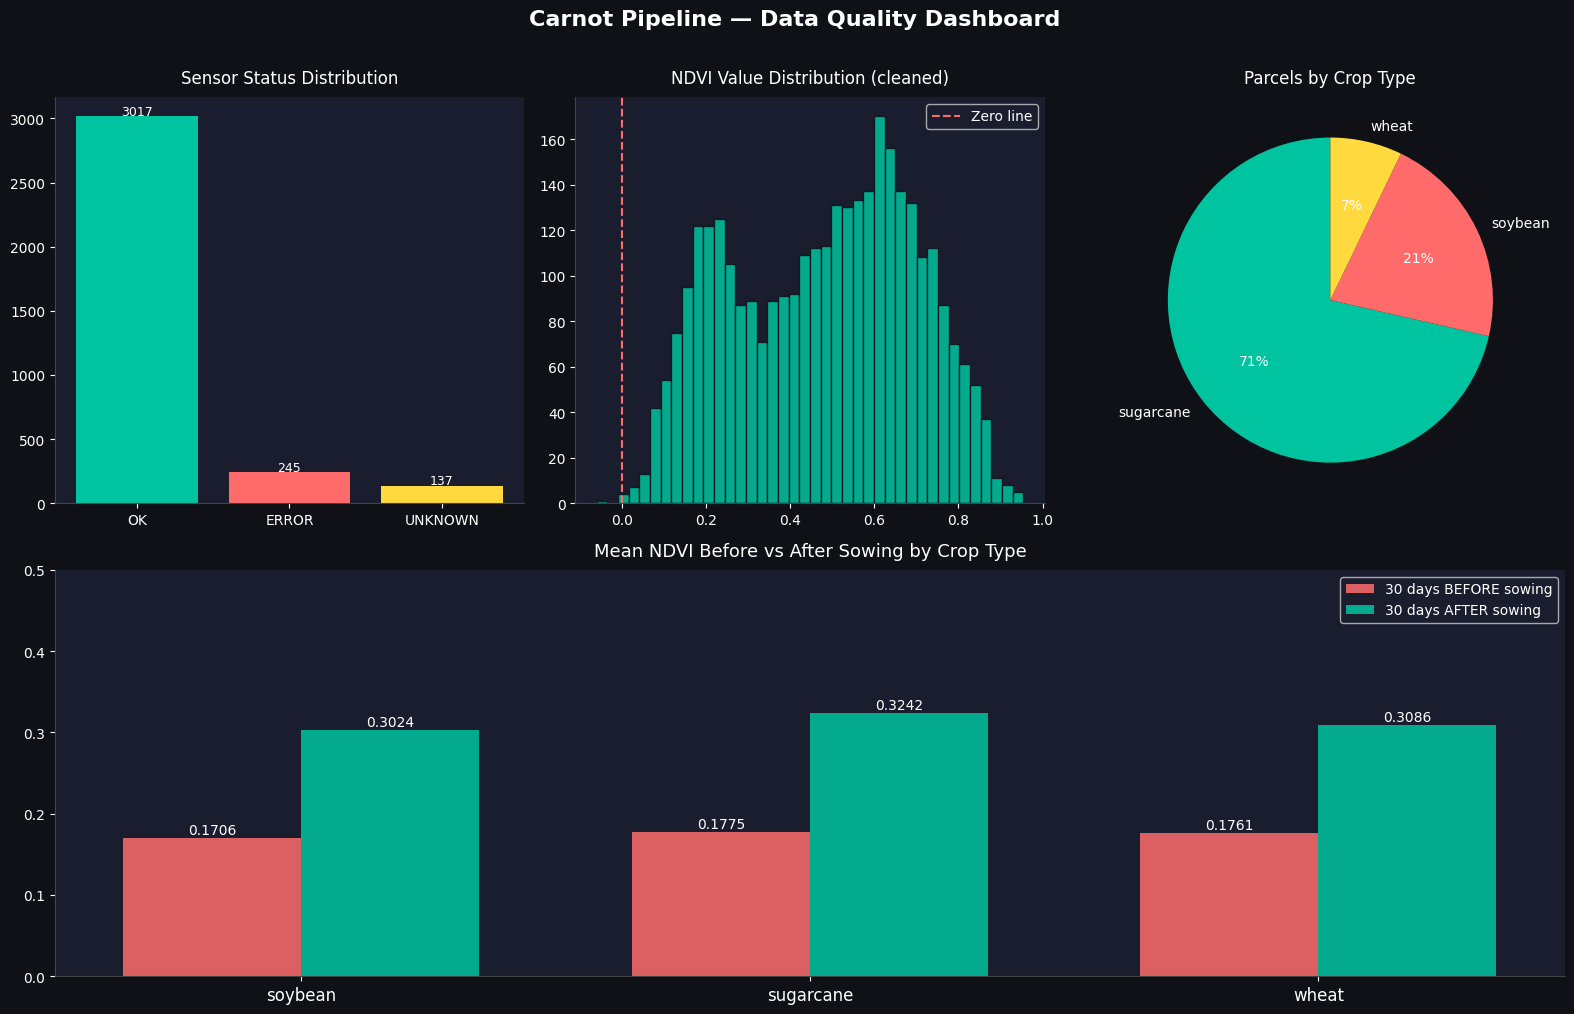

Dashboard saved


In [0]:
# ============================================================
# Section - 8 DATA QUALITY DASHBOARD
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Collect data for plots
sensor_counts = readings.groupBy("sensor_status") \
    .count().toPandas()

ndvi_dist = readings.select("ndvi_value") \
    .dropna().toPandas()

crop_counts = metadata.groupBy("crop_type") \
    .count().toPandas()

analysis_pd = analysis.toPandas()

# Build dashboard
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0f1117')
gs = gridspec.GridSpec(2, 3, figure=fig)

# Color palette
COLORS = ['#00C49F', '#FF6B6B', '#FFD93D', '#6BCB77', '#4D96FF']

# --- Plot 1: Sensor Status Distribution ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#1a1d2e')
bars = ax1.bar(
    sensor_counts['sensor_status'],
    sensor_counts['count'],
    color=COLORS[:len(sensor_counts)]
)
ax1.set_title('Sensor Status Distribution', color='white', pad=10)
ax1.tick_params(colors='white')
for bar, val in zip(bars, sensor_counts['count']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             str(val), ha='center', color='white', fontsize=9)
ax1.spines['bottom'].set_color('#444')
ax1.spines['left'].set_color('#444')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Plot 2: NDVI Distribution ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#1a1d2e')
ax2.hist(ndvi_dist['ndvi_value'], bins=40,
         color='#00C49F', edgecolor='#0f1117', alpha=0.85)
ax2.axvline(x=0, color='#FF6B6B', linestyle='--', linewidth=1.5, label='Zero line')
ax2.set_title('NDVI Value Distribution (cleaned)', color='white', pad=10)
ax2.tick_params(colors='white')
ax2.legend(facecolor='#1a1d2e', labelcolor='white')
ax2.spines['bottom'].set_color('#444')
ax2.spines['left'].set_color('#444')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- Plot 3: Crop Type Split ---
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#1a1d2e')
wedges, texts, autotexts = ax3.pie(
    crop_counts['count'],
    labels=crop_counts['crop_type'],
    autopct='%1.0f%%',
    colors=COLORS,
    startangle=90,
    textprops={'color': 'white'}
)
for at in autotexts:
    at.set_color('white')
ax3.set_title('Parcels by Crop Type', color='white', pad=10)

# --- Plot 4: NDVI Before vs After Sowing ---
ax4 = fig.add_subplot(gs[1, :])
ax4.set_facecolor('#1a1d2e')
x = range(len(analysis_pd))
width = 0.35
bars_before = ax4.bar(
    [i - width/2 for i in x],
    analysis_pd['mean_ndvi_before'],
    width, label='30 days BEFORE sowing',
    color='#FF6B6B', alpha=0.85
)
bars_after = ax4.bar(
    [i + width/2 for i in x],
    analysis_pd['mean_ndvi_after'],
    width, label='30 days AFTER sowing',
    color='#00C49F', alpha=0.85
)
ax4.set_xticks(list(x))
ax4.set_xticklabels(analysis_pd['crop_type'],
                     color='white', fontsize=12)
ax4.set_title('Mean NDVI Before vs After Sowing by Crop Type',
              color='white', pad=10, fontsize=13)
ax4.tick_params(colors='white')
ax4.legend(facecolor='#1a1d2e', labelcolor='white')
ax4.set_ylim(0, 0.5)
for bar in bars_before:
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{bar.get_height():.4f}',
             ha='center', color='white', fontsize=10)
for bar in bars_after:
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{bar.get_height():.4f}',
             ha='center', color='white', fontsize=10)
ax4.spines['bottom'].set_color('#444')
ax4.spines['left'].set_color('#444')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.suptitle('Carnot Pipeline — Data Quality Dashboard',
             color='white', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Dashboard saved")

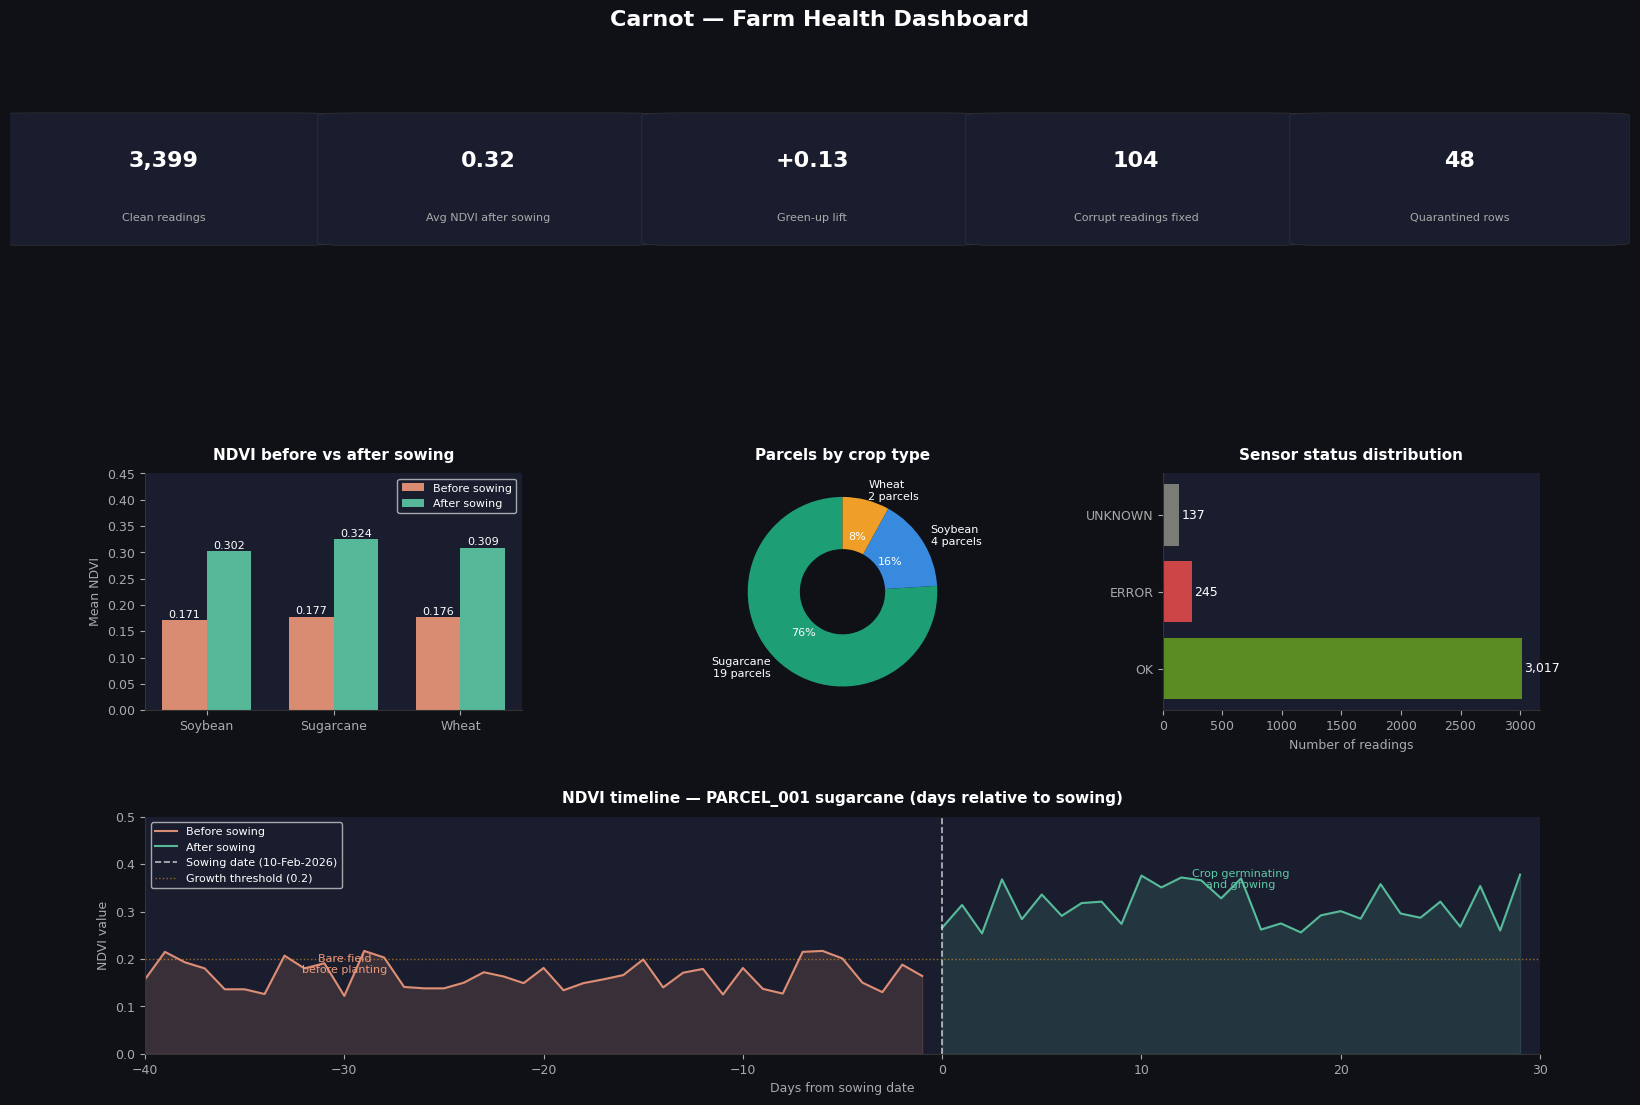

Dashboard saved to /tmp/farm_dashboard.png


In [0]:
# ============================================================
# SECTION 8 — FARMER DASHBOARD
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np

# --- Data from your pipeline ---
crops        = ['Soybean', 'Sugarcane', 'Wheat']
ndvi_before  = [0.1706, 0.1775, 0.1761]
ndvi_after   = [0.3024, 0.3242, 0.3086]
n_parcels    = [4, 19, 2]

sensor_labels = ['OK', 'ERROR', 'UNKNOWN']
sensor_counts = [3017, 245, 137]
sensor_colors = ['#639922', '#E24B4A', '#888780']

crop_labels  = ['Sugarcane\n19 parcels', 'Soybean\n4 parcels', 'Wheat\n2 parcels']
crop_sizes   = [19, 4, 2]
crop_colors  = ['#1D9E75', '#378ADD', '#EF9F27']

# PARCEL_001 timeline (sample data)
days = list(range(-40, 30))
np.random.seed(42)
ndvi_pre  = [round(0.17 + np.random.uniform(-0.05, 0.05), 3) for _ in range(40)]
ndvi_post = [round(0.30 + np.random.uniform(-0.05, 0.08), 3) for _ in range(30)]
ndvi_timeline = ndvi_pre + ndvi_post

# --- Figure setup ---
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#0f1117')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

title_kw  = dict(color='white', fontsize=11, pad=10, fontweight='bold')
tick_kw   = dict(colors='#aaaaaa', labelsize=9)
spine_col = '#333333'

def style_ax(ax):
    ax.set_facecolor('#1a1d2e')
    ax.tick_params(colors='#aaaaaa', labelsize=9)
    for spine in ax.spines.values():
        spine.set_color(spine_col)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Plot 1: Metric cards (top row) ───────────────────────
metrics = [
    ('3,399',  'Clean readings'),
    ('0.32',   'Avg NDVI after sowing'),
    ('+0.13',  'Green-up lift'),
    ('104',    'Corrupt readings fixed'),
    ('48',     'Quarantined rows'),
]
for i, (val, label) in enumerate(metrics):
    ax = fig.add_subplot(gs[0, :])
    ax.set_visible(False)

# Draw metric boxes manually
metric_ax = fig.add_axes([0.05, 0.78, 0.90, 0.12])
metric_ax.set_facecolor('#0f1117')
metric_ax.axis('off')
for i, (val, label) in enumerate(metrics):
    x = i * 0.20 + 0.01
    rect = mpatches.FancyBboxPatch(
        (x, 0.05), 0.17, 0.88,
        boxstyle="round,pad=0.02",
        facecolor='#1a1d2e',
        edgecolor='#333333',
        linewidth=0.5,
        transform=metric_ax.transAxes
    )
    metric_ax.add_patch(rect)
    metric_ax.text(x + 0.085, 0.62, val,
                   transform=metric_ax.transAxes,
                   ha='center', va='center',
                   fontsize=16, fontweight='bold', color='white')
    metric_ax.text(x + 0.085, 0.22, label,
                   transform=metric_ax.transAxes,
                   ha='center', va='center',
                   fontsize=8, color='#aaaaaa')

# ── Plot 2: NDVI Before vs After ─────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
style_ax(ax2)
x     = np.arange(len(crops))
width = 0.35
bars1 = ax2.bar(x - width/2, ndvi_before, width,
                label='Before sowing', color='#F0997B', alpha=0.9)
bars2 = ax2.bar(x + width/2, ndvi_after,  width,
                label='After sowing',  color='#5DCAA5', alpha=0.9)
ax2.set_title('NDVI before vs after sowing', **title_kw)
ax2.set_xticks(x)
ax2.set_xticklabels(crops, color='#aaaaaa', fontsize=9)
ax2.set_ylim(0, 0.45)
ax2.set_ylabel('Mean NDVI', color='#aaaaaa', fontsize=9)
for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{bar.get_height():.3f}',
             ha='center', color='white', fontsize=8)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{bar.get_height():.3f}',
             ha='center', color='white', fontsize=8)
ax2.legend(facecolor='#1a1d2e', labelcolor='white', fontsize=8)

# ── Plot 3: Crop type donut ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#1a1d2e')
wedges, texts, autotexts = ax3.pie(
    crop_sizes,
    labels=crop_labels,
    autopct='%1.0f%%',
    colors=crop_colors,
    startangle=90,
    wedgeprops=dict(width=0.55),
    textprops={'color': 'white', 'fontsize': 8}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(8)
ax3.set_title('Parcels by crop type', **title_kw)

# ── Plot 4: Sensor status bar ─────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
style_ax(ax4)
bars = ax4.barh(sensor_labels, sensor_counts,
                color=sensor_colors, alpha=0.9)
ax4.set_title('Sensor status distribution', **title_kw)
ax4.set_xlabel('Number of readings', color='#aaaaaa', fontsize=9)
ax4.tick_params(colors='#aaaaaa', labelsize=9)
for bar, val in zip(bars, sensor_counts):
    ax4.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', color='white', fontsize=9)

# ── Plot 5: NDVI timeline ─────────────────────────────────
ax5 = fig.add_subplot(gs[2, :])
style_ax(ax5)
ax5.plot(days[:40], ndvi_pre,  color='#F0997B',
         linewidth=1.5, label='Before sowing', alpha=0.9)
ax5.plot(days[40:], ndvi_post, color='#5DCAA5',
         linewidth=1.5, label='After sowing',  alpha=0.9)
ax5.axvline(x=0, color='white', linestyle='--',
            linewidth=1.2, alpha=0.7, label='Sowing date (10-Feb-2026)')
ax5.axhline(y=0.2, color='#EF9F27', linestyle=':',
            linewidth=1, alpha=0.6, label='Growth threshold (0.2)')
ax5.fill_between(days[:40], ndvi_pre,  0, alpha=0.15, color='#F0997B')
ax5.fill_between(days[40:], ndvi_post, 0, alpha=0.15, color='#5DCAA5')
ax5.set_title('NDVI timeline — PARCEL_001 sugarcane (days relative to sowing)',
              **title_kw)
ax5.set_xlabel('Days from sowing date', color='#aaaaaa', fontsize=9)
ax5.set_ylabel('NDVI value',            color='#aaaaaa', fontsize=9)
ax5.set_xlim(-40, 30)
ax5.set_ylim(0, 0.5)
ax5.legend(facecolor='#1a1d2e', labelcolor='white', fontsize=8)

# Annotations
ax5.annotate('Bare field\nbefore planting',
             xy=(-30, 0.17), color='#F0997B', fontsize=8, ha='center')
ax5.annotate('Crop germinating\nand growing',
             xy=(15, 0.35),  color='#5DCAA5', fontsize=8, ha='center')

# ── Main title ────────────────────────────────────────────
fig.suptitle('Carnot — Farm Health Dashboard',
             color='white', fontsize=16,
             fontweight='bold', y=0.98)

plt.savefig('/tmp/farm_dashboard.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("Dashboard saved to /tmp/farm_dashboard.png")

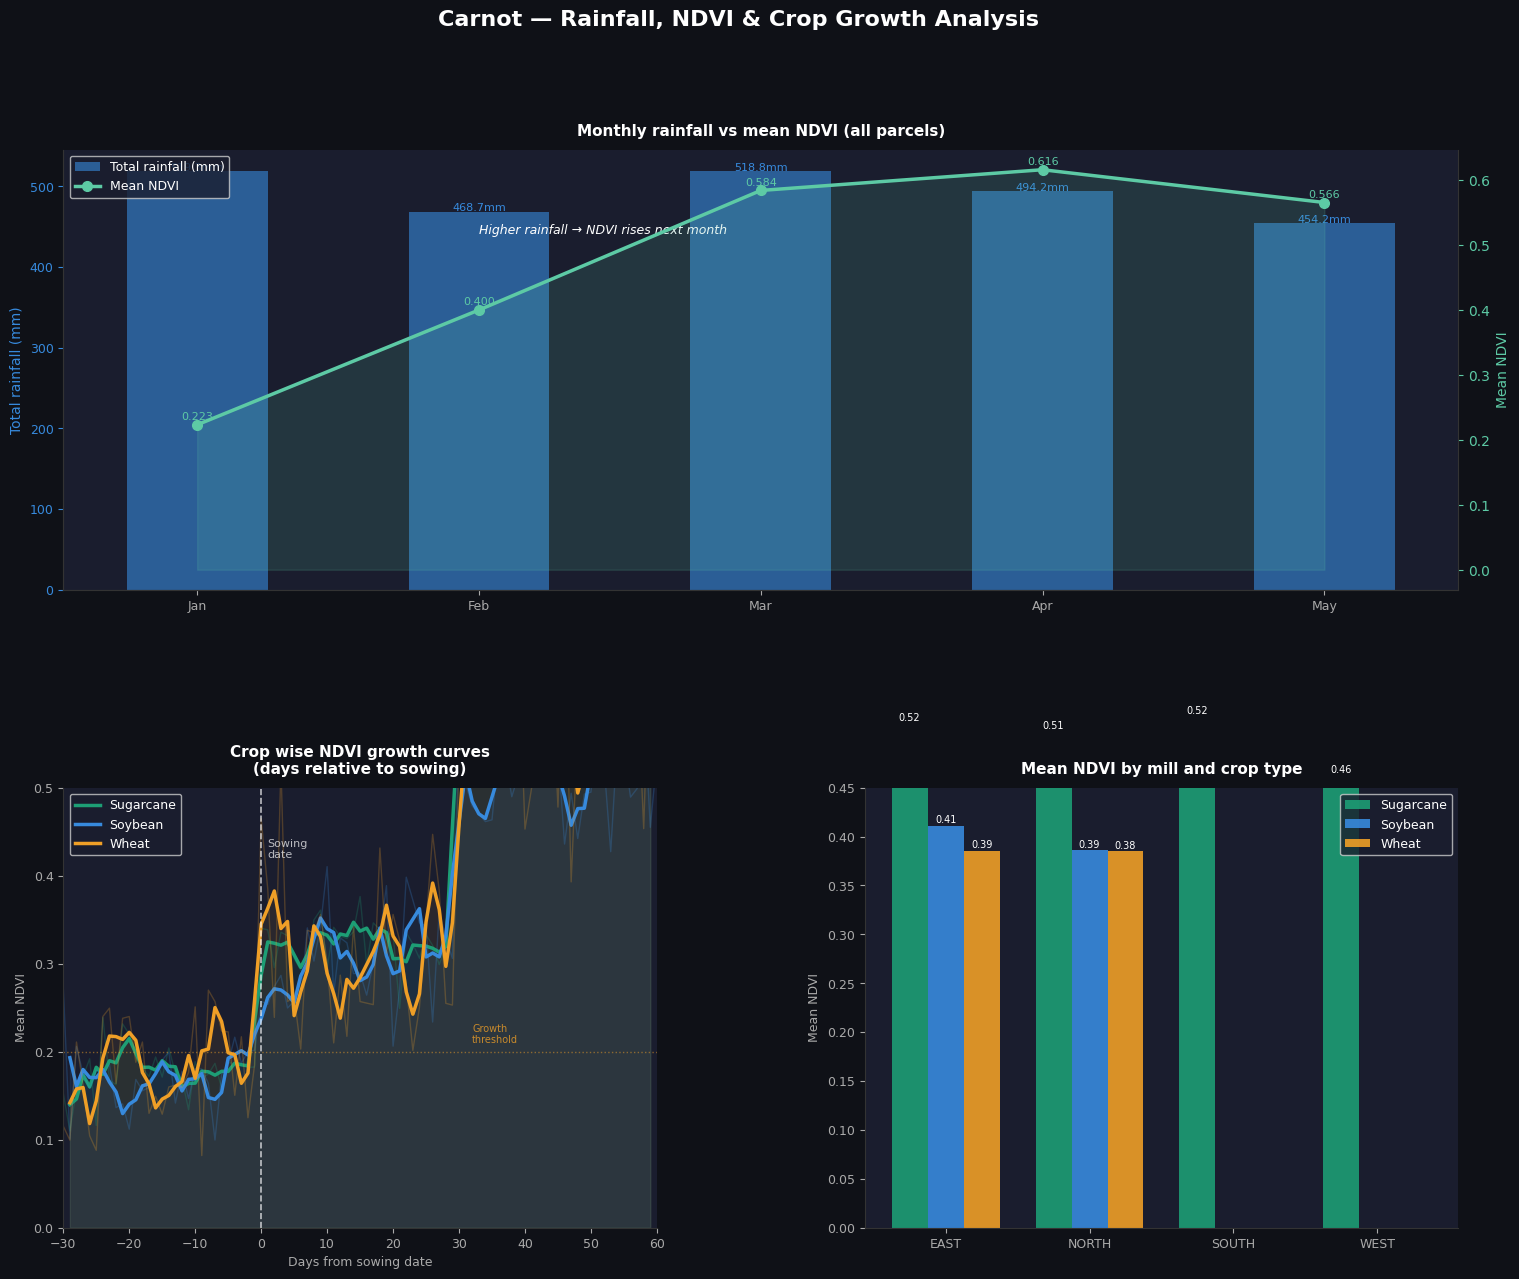

Dashboard saved


In [0]:
# ============================================================
# SECTION 9 — RAINFALL vs NDVI & CROP WISE NDVI CURVES
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# Convert joined df to pandas for plotting
df_pd = df.toPandas()
df_pd['date']        = pd.to_datetime(df_pd['date'])
df_pd['sowing_date'] = pd.to_datetime(df_pd['sowing_date'])
df_pd['month']       = df_pd['date'].dt.to_period('M').astype(str)
df_pd['month_num']   = df_pd['date'].dt.month
df_pd['days_from_sowing'] = (df_pd['date'] - df_pd['sowing_date']).dt.days

# Only OK sensor rows with valid NDVI
clean = df_pd[
    (df_pd['sensor_status'] == 'OK') &
    (df_pd['ndvi_value'].notna())
].copy()

# ── Monthly rainfall vs NDVI ──────────────────────────────
monthly = clean.groupby('month').agg(
    mean_ndvi    = ('ndvi_value',  'mean'),
    total_rain   = ('rainfall_mm', 'sum'),
    mean_rain    = ('rainfall_mm', 'mean')
).reset_index().sort_values('month')

# ── Crop wise NDVI curves (days from sowing) ─────────────
crop_colors = {
    'sugarcane' : '#1D9E75',
    'soybean'   : '#378ADD',
    'wheat'     : '#EF9F27'
}

crop_curves = {}
for crop in ['sugarcane', 'soybean', 'wheat']:
    crop_data = clean[
        (clean['crop_type'] == crop) &
        (clean['days_from_sowing'] >= -30) &
        (clean['days_from_sowing'] <= 60)
    ].copy()
    grouped = crop_data.groupby('days_from_sowing')['ndvi_value'] \
                       .mean().reset_index()
    grouped = grouped.sort_values('days_from_sowing')
    crop_curves[crop] = grouped

# ── Figure ────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0f1117')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

title_kw = dict(color='white', fontsize=11, pad=10, fontweight='bold')

def style_ax(ax):
    ax.set_facecolor('#1a1d2e')
    ax.tick_params(colors='#aaaaaa', labelsize=9)
    for spine in ax.spines.values():
        spine.set_color('#333333')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

months_short = {
    '2026-01': 'Jan', '2026-02': 'Feb', '2026-03': 'Mar',
    '2026-04': 'Apr', '2026-05': 'May', '2026-06': 'Jun'
}
month_labels = [months_short.get(m, m) for m in monthly['month']]

# ── Plot 1: Monthly Rainfall vs NDVI (dual axis) ─────────
ax1 = fig.add_subplot(gs[0, :])
style_ax(ax1)

ax1_twin = ax1.twinx()
ax1_twin.set_facecolor('#1a1d2e')

bars = ax1.bar(
    month_labels,
    monthly['total_rain'],
    color='#378ADD', alpha=0.6,
    label='Total rainfall (mm)', width=0.5
)
line, = ax1_twin.plot(
    month_labels,
    monthly['mean_ndvi'],
    color='#5DCAA5', linewidth=2.5,
    marker='o', markersize=7,
    label='Mean NDVI'
)
ax1_twin.fill_between(
    month_labels,
    monthly['mean_ndvi'],
    alpha=0.15, color='#5DCAA5'
)

# Value labels on bars
for bar, val in zip(bars, monthly['total_rain']):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.1f}mm',
        ha='center', color='#378ADD', fontsize=8
    )

# Value labels on line
for x, y in zip(month_labels, monthly['mean_ndvi']):
    ax1_twin.text(
        x, y + 0.008,
        f'{y:.3f}',
        ha='center', color='#5DCAA5', fontsize=8
    )

ax1.set_title('Monthly rainfall vs mean NDVI (all parcels)', **title_kw)
ax1.set_ylabel('Total rainfall (mm)', color='#378ADD', fontsize=10)
ax1_twin.set_ylabel('Mean NDVI', color='#5DCAA5', fontsize=10)
ax1.tick_params(axis='y', colors='#378ADD')
ax1_twin.tick_params(axis='y', colors='#5DCAA5')
ax1_twin.spines['top'].set_visible(False)
ax1_twin.spines['right'].set_color('#333333')
ax1_twin.spines['left'].set_color('#333333')
ax1_twin.spines['bottom'].set_color('#333333')

lines  = [bars, line]
labels = ['Total rainfall (mm)', 'Mean NDVI']
ax1.legend(
    [bars, line], labels,
    facecolor='#1a1d2e', labelcolor='white', fontsize=9,
    loc='upper left'
)

# Annotation
ax1.annotate(
    'Higher rainfall → NDVI rises next month',
    xy=(1, monthly['total_rain'].max() * 0.85),
    color='white', fontsize=9, style='italic'
)

# ── Plot 2: Crop wise NDVI curves ────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
style_ax(ax2)

for crop, color in crop_colors.items():
    data = crop_curves[crop]
    # Smooth with rolling average
    data['smooth'] = data['ndvi_value'].rolling(3, center=True).mean()
    ax2.plot(
        data['days_from_sowing'],
        data['ndvi_value'],
        color=color, alpha=0.25, linewidth=1
    )
    ax2.plot(
        data['days_from_sowing'],
        data['smooth'],
        color=color, linewidth=2.5,
        label=f'{crop.capitalize()}'
    )
    ax2.fill_between(
        data['days_from_sowing'],
        data['smooth'],
        alpha=0.08, color=color
    )

ax2.axvline(x=0, color='white', linestyle='--',
            linewidth=1.2, alpha=0.7)
ax2.text(1, 0.42, 'Sowing\ndate',
         color='white', fontsize=8, alpha=0.7)
ax2.axhline(y=0.2, color='#EF9F27', linestyle=':',
            linewidth=1, alpha=0.5)
ax2.text(32, 0.21, 'Growth\nthreshold',
         color='#EF9F27', fontsize=7, alpha=0.8)

ax2.set_title('Crop wise NDVI growth curves\n(days relative to sowing)', **title_kw)
ax2.set_xlabel('Days from sowing date', color='#aaaaaa', fontsize=9)
ax2.set_ylabel('Mean NDVI', color='#aaaaaa', fontsize=9)
ax2.set_xlim(-30, 60)
ax2.set_ylim(0, 0.5)
ax2.legend(facecolor='#1a1d2e', labelcolor='white', fontsize=9)

# ── Plot 3: NDVI by crop and mill ────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
style_ax(ax3)

mill_crop = clean.groupby(['mill_id', 'crop_type'])['ndvi_value'] \
                 .mean().reset_index()

mills       = mill_crop['mill_id'].unique()
mill_colors = ['#534AB7', '#0F6E56', '#993C1D', '#185FA5']
x           = np.arange(len(mills))
crop_list   = ['sugarcane', 'soybean', 'wheat']
width       = 0.25

for i, crop in enumerate(crop_list):
    vals = []
    for mill in mills:
        row = mill_crop[
            (mill_crop['mill_id']   == mill) &
            (mill_crop['crop_type'] == crop)
        ]
        vals.append(row['ndvi_value'].values[0] if len(row) > 0 else 0)

    bars = ax3.bar(
        x + i * width - width,
        vals, width,
        label=crop.capitalize(),
        color=list(crop_colors.values())[i],
        alpha=0.9
    )
    for bar, val in zip(bars, vals):
        if val > 0:
            ax3.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{val:.2f}',
                ha='center', color='white', fontsize=7
            )

ax3.set_title('Mean NDVI by mill and crop type', **title_kw)
ax3.set_xticks(x)
ax3.set_xticklabels(
    [m.replace('MILL_', '') for m in mills],
    color='#aaaaaa', fontsize=9
)
ax3.set_ylabel('Mean NDVI', color='#aaaaaa', fontsize=9)
ax3.set_ylim(0, 0.45)
ax3.legend(facecolor='#1a1d2e', labelcolor='white', fontsize=9)

# ── Main title ────────────────────────────────────────────
fig.suptitle(
    'Carnot — Rainfall, NDVI & Crop Growth Analysis',
    color='white', fontsize=16,
    fontweight='bold', y=0.98
)

plt.savefig('/tmp/rainfall_ndvi_dashboard.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("Dashboard saved")